In [2]:
#%matplotlib ipympl
%cd ..

/nfs/users/siddhartha.morales/TTinterpolation/QTT-polynomial-interpolation


/home/users/siddhartha.morales/TTinterpolation/QTT-polynomial-interpolation/.venv/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [13]:

import torch as tn
import torchtt as tntt
import numpy as np
from src.qtt_interpolation.utils import *
from src.qtt_interpolation.qttnoise import *
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from mpl_toolkits.mplot3d import Axes3D

In [4]:
depth = 10
octaves = 9
H = 0.9
mpsm = mid_point_1d(depth,octaves=octaves, nrank=5,var=1,eps=1e-12, H = H)

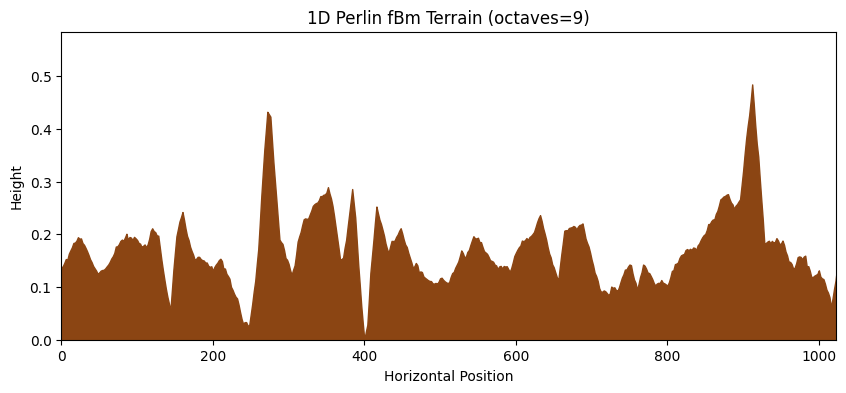

In [5]:
terrain_heights = mpsm.full().flatten()
terrain_heights -= terrain_heights.min()
fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(2**depth)
ax.fill_between(x, terrain_heights, color='saddlebrown')
ax.set_ylim(0, terrain_heights.max()+.1)
ax.set_xlim(0, 2**depth -1)
ax.set_title(f"1D Perlin fBm Terrain (octaves={octaves})")
ax.set_xlabel("Horizontal Position")
ax.set_ylabel("Height")
plt.show()

In [74]:
def mid_point_2d(ncores,iscale=1,octaves=None, nrank=10,var=1,eps=1e-10, alpha=0.5,H = 1,amp = 1):

    if octaves==None:
        octaves = ncores
    elif octaves + iscale > ncores:
        octaves = ncores - iscale
    depth = ncores
    w = alpha**(H)
    r = nrank
    mpsm = 0
    for i in range(iscale,iscale + octaves+1):
        if  i == ncores :
            delta = tntt.kron(tntt.ones([2,2]*(i-1)),tntt.TT(tn.tensor([0,1,1,1],dtype=tn.float64),[2,2]) )
            noise = tntt.randn([4]*i,[1]+[r]*(i-1)+[1],var=var).to_qtt(rmax=nrank)
            noise = noise*delta
            mpsm += amp * noise
            #mpsm = (mpsm).round(eps)
        else:
            phi1 = tntt.TT(qtt_polynomial_cores([1,-1], depth-i))
            phi2 = tntt.TT(qtt_polynomial_cores([0,1], depth-i))
            ones = tntt.ones([2,2]*i)
            onesf = tntt.ones([2]*(depth-i))
            oneso = tntt.eye([2]*(depth-i))
            zones2 = zukron(onesf, onesf)
            Px = [tntt.kron(ones,zukron(phi1,onesf)),tntt.kron(ones,zukron(phi2,onesf))]
            Py = [tntt.kron(ones,zukron(onesf,phi1)),tntt.kron(ones,zukron(onesf,phi2))]
            # define shift matrix
            if i == 1:
                noise = tntt.TT(tn.randn(4, dtype=tn.float64),[2,2])
                
                noise = tntt.kron(noise,zones2)
                M = tntt.TT(tn.tensor([[0,1],[1,0]],dtype=tn.float64),[(2,2)])
                id = tntt.kron( tntt.eye([2]), oneso)
                S = tntt.kron( M, oneso)
                Sx = zukron(S,id)
                Sy = zukron(id,S)

                #interpolate x

                mpsm = noise * Px[0] + (Sx@noise) * Px[1]

                #interpolate y
                mpsm = mpsm * Py[0] + (Sy@mpsm) * Py[1]
                
            
            else:
                delta = tntt.kron(tntt.ones([2,2]*(i-1)),tntt.TT(tn.tensor([0,1,1,1],dtype=tn.float64),[2,2]) )
                noise = tntt.randn([4]*i,[1]+[r]*(i-1)+[1],var=var).to_qtt(rmax=nrank)
                noise = noise*delta
                S = tntt.kron(P_qtt( 2**i -1, i),oneso)
                id = tntt.kron( tntt.eye([2]*i), oneso)
                Sx = zukron(S,id)
                Sy = zukron(id,S)
                noise = tntt.kron(noise,zones2)

                #interpolate x
                level = noise * Px[0] + (Sx@noise) * Px[1]

                #interpolate y
                level = level * Py[0] + (Sy@level) * Py[1]
                
                mpsm += amp * level
        
        amp *= w
        mpsm = mpsm.round(eps)

    return mpsm

In [89]:
depth = 10
iscale= 2
octaves = depth 
H = 1
amp = 0.8
mpsm = mid_point_2d(depth,iscale=iscale,octaves=octaves, nrank=5,var=1,eps=1e-5, H = H)
terr = z_order_to_normal_torch(mpsm.full().flatten(),2**depth, 2**depth)
#terr /= terr.max()

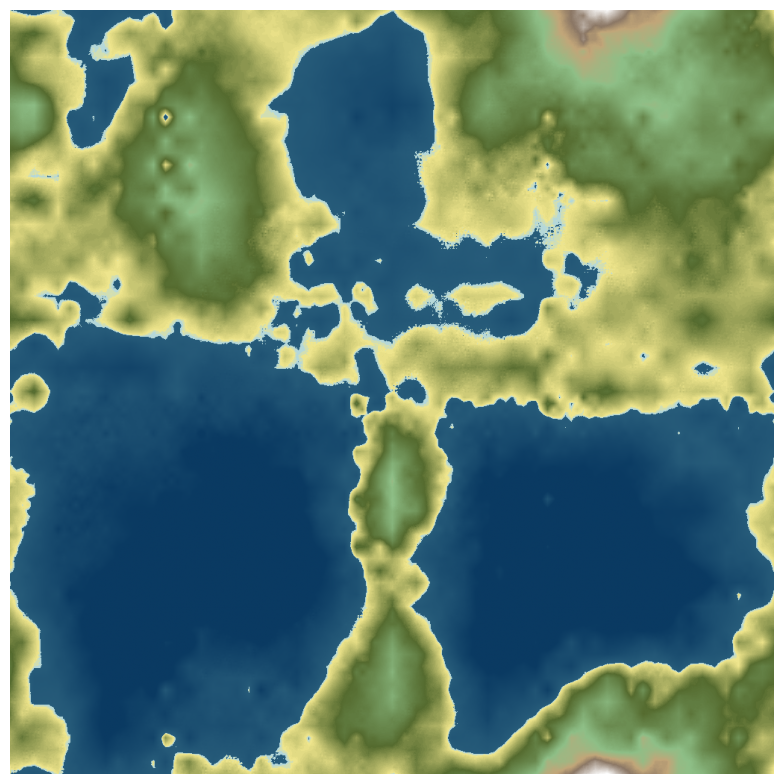

In [90]:
# — normalize heightmap to [0,1] —
terr = (terr - terr.min()) / (terr.max() - terr.min()) 
# USGS-style realistic terrain colormap
sea_level   = 0.5
land        = 1.0 - sea_level
deep_end    = sea_level * 0.6
shallow_end = sea_level
dune_end    = sea_level + land * 0.02
low_end     = sea_level + land * 0.20
mid_end     = sea_level + land * 0.50
high_end    = sea_level + land * 0.65
rock_end    = sea_level + land * 0.75
snow_end    = 1.0

colors = [
    (0.00,        '#0A3A62'),  # deep ocean
    (deep_end,    '#0A3A62'),
    (shallow_end, '#275C7A'),  # shallow ocean
    (sea_level,   '#A7D5ED'),  # coastal water
    (dune_end,    '#F0E68C'),  # sandy beach
    (low_end,     '#556B2F'),  # lowland grass
    (mid_end,     '#8EBF87'),  # rolling hills
    (high_end,    '#C2A679'),  # uplands
    (rock_end,    '#8B7765'),  # bare rock
    (snow_end,    '#FFFFFF'),  # snow caps
]
cmap = LinearSegmentedColormap.from_list('RealisticTerrain', colors)
#cmap = Colormap('colorbrewer:brbg')
# Plot
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(
    terr,
    cmap=cmap,
    origin='lower',
    extent=[0, 1, 0, 1]
)
ax.axis('off')
plt.tight_layout()
plt.show()
fig.savefig('./examples/figs/terrain_ex.png', dpi=200, bbox_inches='tight')

In [12]:
tntt.save(mpsm,'./examples/data/2dterrain.TT')

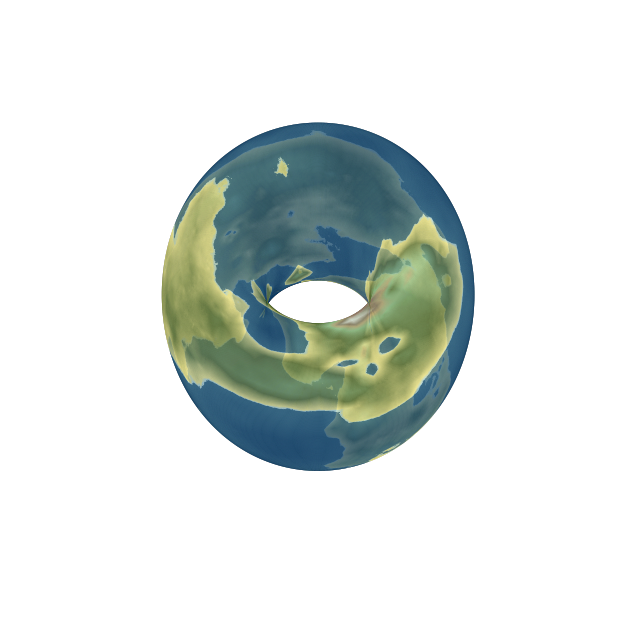

In [ ]:

M, N = terr.shape
u = np.linspace(0, 2*np.pi, N)
v = np.linspace(0, 2*np.pi, M)
U, V = np.meshgrid(u, v)

R, r = 2.0, 1.0
X = (R + r*np.cos(V)) * np.cos(U)
Y = (R + r*np.cos(V)) * np.sin(U)
Z = r * np.sin(V)
facecolors = cmap(terr)

fig = plt.figure(figsize=(10, 6))
ax  = fig.add_axes([0, 0, 1, 1], projection='3d')  # <-- full‑figure axes

ax.plot_surface(
    X, Y, Z,
    rstride=1, cstride=1,
    facecolors=facecolors,
    shade=False, linewidth=0
)

ax.set_box_aspect([1,1,1])
ax.view_init(elev=70, azim=45)
ax.set_axis_off()

# When saving, force zero padding around the *figure*
fig.savefig(
    './examples/figs/torus_terrain_u.png',
    dpi=200,
    bbox_inches='tight',
    pad_inches=0
)
plt.show()


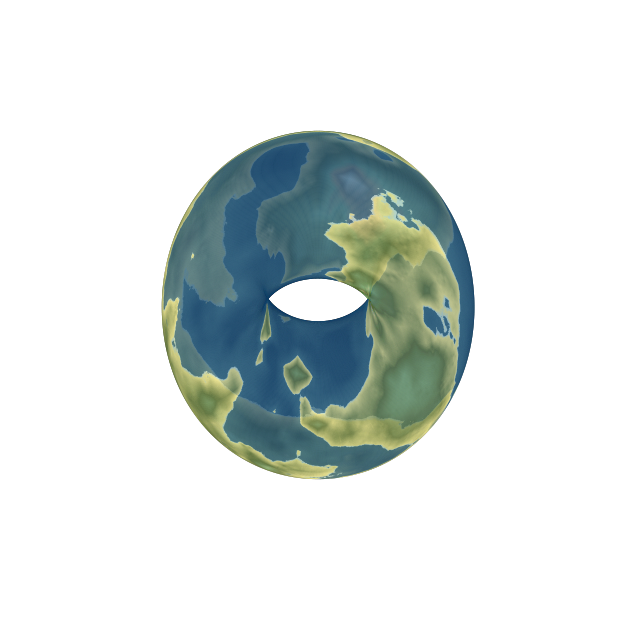

In [110]:

fig2 = plt.figure(figsize=(10, 6))
ax2 = fig2.add_axes([0, 0, 1, 1], projection='3d')

ax2.plot_surface(
    X, Y, Z,
    rstride=1, cstride=1,
    facecolors=facecolors,
    shade=False, linewidth=0
)

ax2.set_box_aspect([1,1,1])
ax2.view_init(elev=-70, azim=45)  # look from below, same azimuth
ax2.set_axis_off()

fig2.savefig(
    './examples/figs/torus_terrain_b.png',
    dpi=200,
    bbox_inches='tight',
    pad_inches=0
)
plt.show()

### Another 70's color map

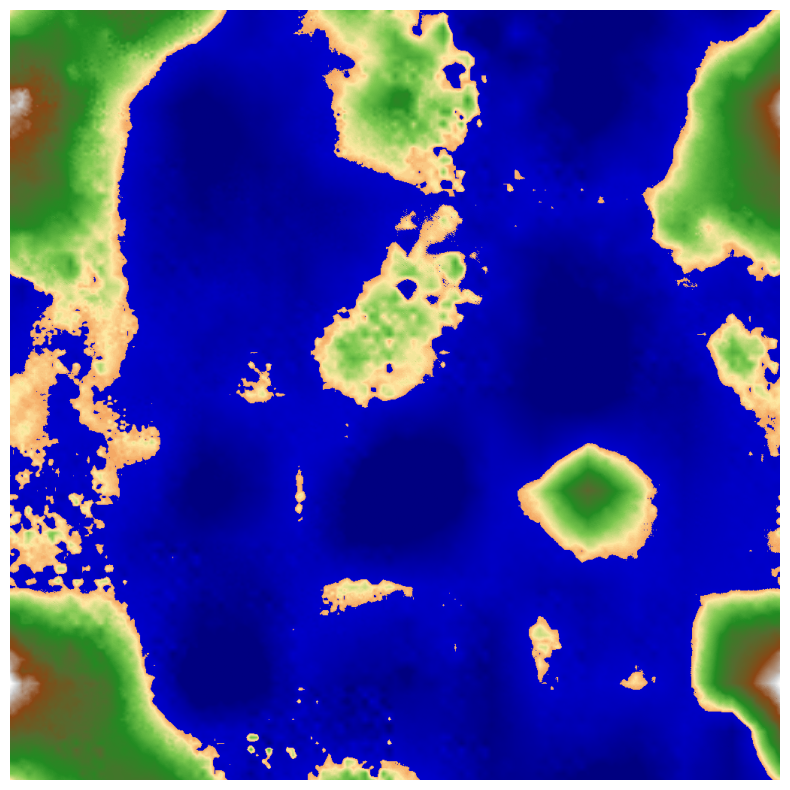

In [27]:
# — normalize heightmap to [0,1] —
terr = (terr - terr.min())/(terr.max() - terr.min())

# — user‐tweakable parameters —
sea_level        = 0.5   # waterline
deep_frac        = 0.6   # deep→shallow break (fraction of sea)
dune_frac        = 0.05  # tiny sand dune above beach
grass_low_frac   = 0.15  # first grass band
grass_high_frac  = 0.30  # second grass band
hill_frac        = 0.50  # foothills
rock_frac        = 0.70  # bare rock
peak_frac        = 0.90  # high-altitude scree

# — compute absolute positions on [0,1] —
sea   = sea_level
land  = 1.0 - sea_level

deep_end       = sea * deep_frac
shallow_end    = sea
dune_end       = sea + land * dune_frac
grass_low_end  = sea + land * grass_low_frac
grass_high_end = sea + land * grass_high_frac
hill_end       = sea + land * hill_frac
rock_end       = sea + land * rock_frac
peak_end       = sea + land * peak_frac
snow_end       = 1.0

# — assemble (position, color) list —
colors = [
    (0.00, deep_color   := '#000080'),  # deep ocean
    (deep_end, deep_color),
    (shallow_end, '#0000cd'),           # shallow ocean
    (sea, '#f4a460'),                   # beach / sand
    (dune_end, '#ffe9a3'),              # sand dunes
    (grass_low_end, '#7ec850'),         # light grass
    (grass_high_end, '#228b22'),        # dark grass
    (hill_end, '#556b2f'),              # foothills
    (rock_end, '#8b4513'),              # bare rock
    (peak_end, '#cccccc'),              # scree / high rock
    (snow_end, '#ffffff'),              # snow caps
]

cmap = LinearSegmentedColormap.from_list('VeryDetailedTerrain', colors)

# — plot with no axes, no interpolation —
fig, ax = plt.subplots(figsize=(8,8))
ax.imshow(
    terr,
    cmap=cmap,
    origin='lower',
    extent=[0,1,0,1],
)
ax.axis('off')
plt.tight_layout()
plt.show()

# Metrics

In [105]:
import pandas as pd

reps = 50
H = 1
amp = 0.8
iscale= 2
max_ranks, eranks, compression, scales = [],[],[],[]

for d in range(8,19):
    print('doind d...', d)
    depth = d
    octaves = depth 
    for r in range(reps):
        mps = mid_point_2d(depth,iscale=iscale,octaves=octaves, nrank=5,var=1,eps=1e-6, H = H)
        entries = sum([tn.numel(c) for c in mps.cores])
        comp = entries / np.prod(np.array(mps.N, dtype=np.float64))

        scales.append(d)
        max_ranks.append(np.max(mps.R))
        eranks.append(erank(mps.R,mps.N))
        compression.append(comp)


doind d... 8
doind d... 9
doind d... 10
doind d... 11
doind d... 12
doind d... 13
doind d... 14
doind d... 15
doind d... 16
doind d... 17
doind d... 18


In [108]:

# … assume scales, compression, max_ranks, eranks are defined …

# Build DataFrame and stats
df = pd.DataFrame({
    'scale':    scales,
    'compression': compression,
    'max_rank':    max_ranks,
    'erank':       eranks
})

df.to_csv('./metrics/data/terrainM.csv', index=False)


In [111]:
import matplotlib.image as mpimg
from matplotlib.ticker import LogFormatterSciNotation

/tmp/ipykernel_824841/3868517487.py:88: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


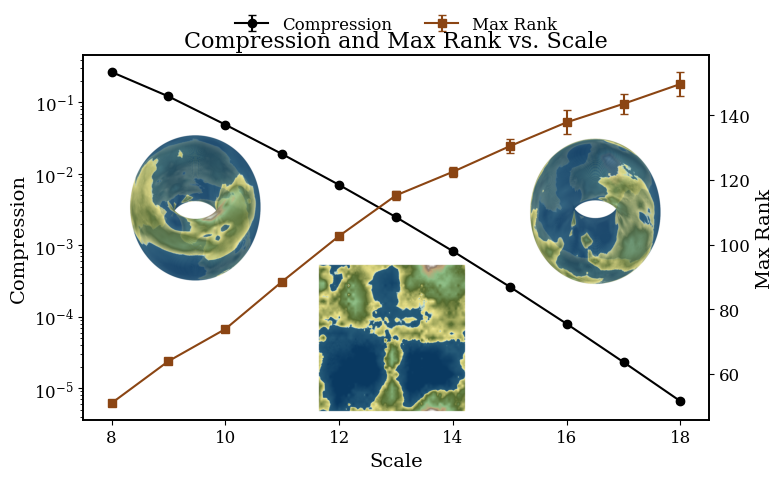

In [125]:

cm = df.groupby('scale')['compression'].mean()
cs = df.groupby('scale')['compression'].std()
rm = df.groupby('scale')['max_rank'].mean()
rs = df.groupby('scale')['max_rank'].std()

# 2) LaTeX style
plt.rc('font', family='serif', size=12)
plt.rc('mathtext', fontset='cm')

# 3) Main plot
fig, ax1 = plt.subplots(figsize=(8,5))

# – Compression on left y-axis –
ax1.errorbar(
    cm.index, cm.values, yerr=cs.values,
    fmt='-o', color='#000000', capsize=3, label='Compression'
)
ax1.set_xlabel('Scale', fontsize=14, color='black')
ax1.set_ylabel('Compression', fontsize=14, color='black')
ax1.set_yscale('log')
ax1.yaxis.set_major_formatter(LogFormatterSciNotation())

# – Max Rank on right y-axis –
ax2 = ax1.twinx()
ax2.errorbar(
    rm.index, rm.values, yerr=rs.values,
    fmt='-s', color='#8B4513', capsize=3, label='Max Rank'
)
ax2.set_ylabel('Max Rank', fontsize=14, color='black')

# 4) Style: no grids, black spines & ticks
ax1.grid(False)
ax2.grid(False)
for ax in (ax1, ax2):
    for spine in ax.spines.values():
        spine.set_linewidth(1.2)
        spine.set_color('black')
    ax.tick_params(colors='black')

# 5) Legend above, centered
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(
    h1+h2, l1+l2,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.15),
    ncol=2,
    frameon=False,
    fontsize=12
)


plt.title(r'Compression and Max Rank vs. Scale', fontsize=16, color='black')

# 6) Insets (lower center, mid left, mid right)
img_center = mpimg.imread('./examples/figs/terrain_ex.png')
axins_center = fig.add_axes([0.30, 0.15, 0.40, 0.30])
axins_center.imshow(img_center)
axins_center.axis('off')
axins_center.set_zorder(0)

img_left = mpimg.imread('./examples/figs/torus_terrain.png')
axins_left = fig.add_axes([0.00, 0.3, 0.50, 0.50])
axins_left.imshow(img_left)
axins_left.axis('off')
axins_left.set_zorder(1)

img_right = mpimg.imread('./examples/figs/torus_terrain_b.png')
axins_right = fig.add_axes([0.5, 0.3, 0.50, 0.50])
axins_right.imshow(img_right)
axins_right.axis('off')
axins_right.set_zorder(0)

# 7) Pull main axes above the insets
ax1.set_zorder(2)
ax2.set_zorder(2)
ax1.patch.set_visible(False)

# 8) Save (optional)

fig.savefig(
    './metrics/plots/terrain_metrics_fill.pdf',
    format='pdf',
    bbox_inches='tight',
    pad_inches=0
)

plt.tight_layout()
plt.show()
